(np.float64(-0.5), np.float64(4283.5), np.float64(5711.5), np.float64(-0.5))

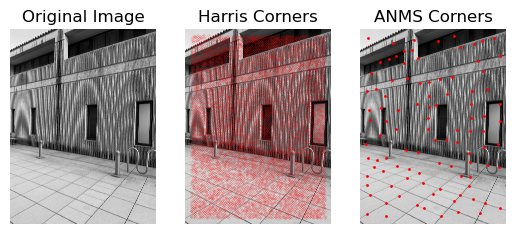

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageOps, ImageFilter
from harris2 import *

def gaussian_downsample_np(img_np, sigma=1.0):
    img_pil = Image.fromarray((img_np * 255.0).astype(np.uint8))
    img_blur = img_pil.filter(ImageFilter.GaussianBlur(radius=sigma))
    new_size = (img_pil.width // 2, img_pil.height // 2)
    img_small = img_blur.resize(new_size, resample=Image.BILINEAR)
    return np.asarray(img_small, dtype=np.float32) / 255.0

def build_gaussian_pyramid(img_np, levels=None, max_side=None, sigma=1.0):
    pyr = [img_np.astype(np.float32)]
    if max_side is not None:
        H, W = img_np.shape[:2]
        cur_max = max(H, W)
        while cur_max > max_side and min(pyr[-1].shape[:2]) >= 2:
            pyr.append(gaussian_downsample_np(pyr[-1], sigma=sigma))
            cur_max = max(pyr[-1].shape[:2])
    else:
        for _ in range(levels):
            if min(pyr[-1].shape[:2]) < 2:
                break
            pyr.append(gaussian_downsample_np(pyr[-1], sigma=sigma))
    return pyr

def upscale_coords(coords, scale):
    ys, xs = coords
    ys_up = (ys.astype(np.float64) * scale).round().astype(int)
    xs_up = (xs.astype(np.float64) * scale).round().astype(int)
    return np.vstack([ys_up, xs_up])

def anms(h, coords, num_keep, c_robust=0.9, return_radius=True):
    ys, xs = coords
    N = coords.shape[1]
    if N == 0:
        return coords, np.array([]), np.array([]) if return_radius else coords

    strengths = h[ys, xs].astype(np.float64)  # shape (N,)

    pts = np.stack([ys, xs], axis=1).astype(np.float64)  # (N, 2)

    D2 = dist2(pts, pts)  # (N, N)
    np.fill_diagonal(D2, np.inf)

    stronger_mask = strengths[None, :] > (c_robust * strengths[:, None])

    g = int(np.argmax(strengths))
    idxs = np.arange(N)
    not_g = idxs != g
    stronger_mask[not_g, g] = strengths[g] >= (c_robust * strengths[not_g])

    D2_masked = D2.copy()
    D2_masked[~stronger_mask] = np.inf

    r2 = np.min(D2_masked, axis=1)  # (N,)
    r2[g] = np.inf

    order = np.argsort(-r2)
    K = min(num_keep, N)
    keep_idx = order[:K]

    sel_coords = coords[:, keep_idx]
    if return_radius:
        sel_radius = np.sqrt(r2[keep_idx])
        sel_strength = strengths[keep_idx]
        return sel_coords, sel_radius, sel_strength
    else:
        return sel_coords

img1_path = "wall/w1.jpg"
img2_path = "wall/w3.jpg"

# img1_path = "building1/bo1.jpg"
# img2_path = "building1/bo3.jpg"


# img1_path = "building2/bt2.jpg"
# img2_path = "building2/bt4.jpg"

img = Image.open(img1_path).convert("RGB")
img = ImageOps.exif_transpose(img)
img_gray = ImageOps.grayscale(img)
img_np = np.array(img_gray) / 255.0

img2 = Image.open(img2_path).convert("RGB")
img2 = ImageOps.exif_transpose(img2)
img_gray2 = ImageOps.grayscale(img2)
img_np2 = np.array(img_gray2) / 255.0


fig, ax = plt.subplots(1, 3)
ax[0].imshow(img_np, cmap="gray")
ax[0].set_title("Original Image")
ax[0].axis('off')

pyr = build_gaussian_pyramid(img_np, levels=3)
pyr2 = build_gaussian_pyramid(img_np2, levels=3)
L = len(pyr) - 1
img_small = pyr[L]
img_small2 = pyr2[L]
scale_factor = 2 ** L

h_small, coords_small = get_harris_corners(img_small)
h_small2, coords_small2 = get_harris_corners(img_small2)
coords_small_anms = anms(h_small, coords_small, num_keep=100, c_robust=0.9, return_radius=False)
coords_small_anms2 = anms(h_small2, coords_small2, num_keep=100, c_robust=0.9, return_radius=False)

coords_on_full = upscale_coords(coords_small, scale_factor)
coords_on_full_anms = upscale_coords(coords_small_anms, scale_factor)
coords_on_full2 = upscale_coords(coords_small2, scale_factor)
coords_on_full_anms2 = upscale_coords(coords_small_anms2, scale_factor)

ax[1].imshow(img_np, cmap="gray")
ax[1].scatter(coords_on_full[1], coords_on_full[0], s=0.01, c='r')
ax[1].set_title("Harris Corners")
ax[1].axis('off')

ax[2].imshow(img_np, cmap="gray")
ax[2].scatter(coords_on_full_anms[1], coords_on_full_anms[0], s=1, c='r')
ax[2].set_title("ANMS Corners")
ax[2].axis('off')

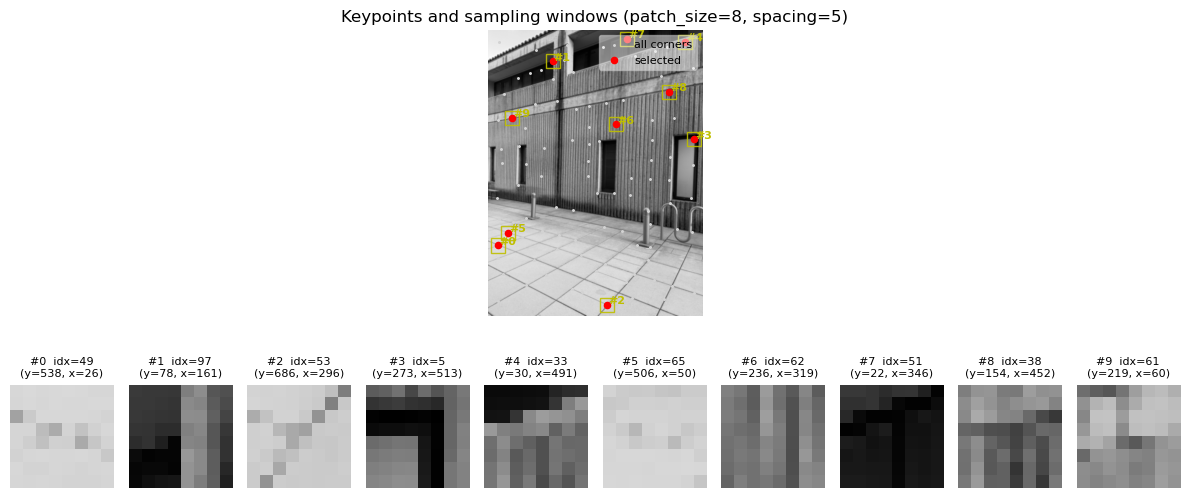

In [2]:
from matplotlib.patches import Rectangle
import random

def _reflect_indices(idx, M):
    t = np.mod(idx, 2 * M)
    t = np.where(t < 0, t + 2 * M, t)
    return np.where(t >= M, 2 * M - 1 - t, t).astype(np.int64)

def _edge_indices(idx, M):
    return np.clip(idx, 0, M - 1).astype(np.int64)

def bilinear_sample(img, ys, xs, border="reflect"):
    H, W = img.shape
    y0 = np.floor(ys).astype(np.int64); x0 = np.floor(xs).astype(np.int64)
    y1 = y0 + 1;                       x1 = x0 + 1

    wy = ys - y0; wx = xs - x0
    wy0 = 1.0 - wy; wx0 = 1.0 - wx

    if border == "reflect":
        y0i = _reflect_indices(y0, H); y1i = _reflect_indices(y1, H)
        x0i = _reflect_indices(x0, W); x1i = _reflect_indices(x1, W)
    elif border == "edge":
        y0i = _edge_indices(y0, H);    y1i = _edge_indices(y1, H)
        x0i = _edge_indices(x0, W);    x1i = _edge_indices(x1, W)
    else:
        raise ValueError("border must be 'reflect' or 'edge'")

    Ia = img[y0i, x0i]; Ib = img[y0i, x1i]
    Ic = img[y1i, x0i]; Id = img[y1i, x1i]

    out = (Ia * wy0 * wx0 +
           Ib * wy0 * wx  +
           Ic * wy  * wx0 +
           Id * wy  * wx ).astype(np.float32)
    return out

def extract_descriptors(
    img_gray,
    coords,              
    patch_size=8,       
    spacing=5,            
    border="reflect",      
    return_patches=False
):
    img = img_gray.astype(np.float32, copy=False)
    ys, xs = coords
    N = coords.shape[1]

    half = (patch_size / 2 - 0.5) * spacing
    offsets = np.linspace(-half, half, patch_size, dtype=np.float32)

    descs = np.empty((N, patch_size * patch_size), dtype=np.float32)
    patches = np.empty((N, patch_size, patch_size), dtype=np.float32) if return_patches else None

    for i in range(N):
        y0, x0 = float(ys[i]), float(xs[i])

        grid_y = (y0 + offsets[:, None]).repeat(patch_size, axis=1)  # (8,8)
        grid_x = (x0 + offsets[None, :]).repeat(patch_size, axis=0)  # (8,8)

        patch = bilinear_sample(img, grid_y, grid_x, border=border)

        vec = patch.reshape(-1).astype(np.float32)
        m = vec.mean(); s = vec.std()
        if s < 1e-6:
            vec = vec - m
        else:
            vec = (vec - m) / s

        descs[i] = vec
        if return_patches:
            patches[i] = patch

    return (descs, patches) if return_patches else descs

def visualize_patches(
    img_gray,
    coords, 
    patches, 
    n=10, 
    idxs=None, 
    patch_size=8,
    spacing=5,
    figsize=(12, 6),
    seed=None
):
    N = coords.shape[1]

    ys, xs = coords
    n = min(n, N)

    if idxs is None:
        if seed is not None:
            random.seed(seed)
        idxs = random.sample(range(N), n)
    else:
        idxs = list(idxs)
        n = min(n, len(idxs))

    half = (patch_size / 2 - 0.5) * spacing
    side = 2 * half

    cols = min(n, 10)
    rows = int(np.ceil(n / cols))
    fig = plt.figure(figsize=figsize)

    ax_main = plt.subplot2grid((rows + 1, cols), (0, 0), colspan=cols)
    ax_main.imshow(img_gray, cmap='gray')
    ax_main.scatter(xs, ys, s=5, c='lightgray', marker='.', label='all corners')
    ax_main.scatter(xs[idxs], ys[idxs], s=20, c='r', marker='o', label='selected')

    for j, i in enumerate(idxs):
        y0, x0 = float(ys[i]), float(xs[i])
        rect = Rectangle(
            (x0 - side / 2, y0 - side / 2),
            side, side,
            linewidth=1.0, edgecolor='y', facecolor='none', alpha=0.9
        )
        ax_main.add_patch(rect)
        ax_main.text(x0 + 3, y0 - 3, f'#{j}', color='y', fontsize=8, weight='bold')

    ax_main.set_title(f"Keypoints and sampling windows (patch_size={patch_size}, spacing={spacing})")
    ax_main.axis('off')
    ax_main.legend(loc='upper right', fontsize=8, framealpha=0.5)

    for j in range(n):
        i = idxs[j]
        ax = plt.subplot2grid((rows + 1, cols), (1 + j // cols, j % cols))
        ax.imshow(patches[i], cmap='gray', vmin=0.0, vmax=1.0)
        ax.set_title(f'#{j}  idx={i}\n(y={ys[i]}, x={xs[i]})', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return idxs


descs_small, patches_small = extract_descriptors(
    img_gray=img_small,
    coords=coords_small_anms,
    patch_size=8,
    spacing=5,
    border="reflect",
    return_patches=True
)

_ = visualize_patches(
    img_gray=img_small,
    coords=coords_small_anms,
    patches=patches_small,
    n=10,
    patch_size=8,
    spacing=5,
    seed=0
)

In [ ]:
def pairwise_ssd(a, b, chunk_size=None):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    N1, D = a.shape
    N2 = b.shape[0]
    assert b.shape[1] == D

    if chunk_size is None or N1 * N2 <= 1_000_000:
        a2 = np.sum(a*a, axis=1, keepdims=True)        # (N1,1)
        b2 = np.sum(b*b, axis=1, keepdims=True).T      # (1,N2)
        return a2 + b2 - 2.0 * (a @ b.T)

    Dmat = np.empty((N1, N2), dtype=np.float32)
    for s in range(0, N1, chunk_size):
        e = min(s + chunk_size, N1)
        a_blk = a[s:e]
        a2 = np.sum(a_blk*a_blk, axis=1, keepdims=True)
        b2 = np.sum(b*b, axis=1, keepdims=True).T
        Dmat[s:e] = a2 + b2 - 2.0 * (a_blk @ b.T)
    return Dmat

def match_descriptors_ratio(
    desc1, desc2, coords1, coords2,
    ratio_thresh=0.7,
    mutual_check=True,
    return_scores=False,
    dist_chunk=None
):
    D = pairwise_ssd(desc1, desc2, chunk_size=dist_chunk)  # (N1, N2)

    nn2 = np.argpartition(D, kth=1, axis=1)[:, :2]
    i0 = np.arange(nn2.shape[0])
    d0 = D[i0, nn2[:,0]]
    d1 = D[i0, nn2[:,1]]
    swap = d1 < d0
    best_idx   = np.where(swap, nn2[:,1], nn2[:,0]) 
    second_idx = np.where(swap, nn2[:,0], nn2[:,1]) 
    e1 = D[i0, best_idx] + 1e-12
    e2 = D[i0, second_idx] + 1e-12
    ratios = e1 / e2

    keep = ratios < ratio_thresh
    cand_i1 = np.nonzero(keep)[0]
    cand_i2 = best_idx[keep]
    cand_rat = ratios[keep]

    if mutual_check:
        D_T = D.T  # (N2, N1)
        best_from2 = np.argmin(D_T, axis=1)
        mutual = best_from2[cand_i2] == cand_i1
        cand_i1 = cand_i1[mutual]
        cand_i2 = cand_i2[mutual]
        cand_rat = cand_rat[mutual]

    matches = np.stack([cand_i1, cand_i2], axis=1)
    return (matches, cand_rat) if return_scores else matches


def draw_matches_side_by_side(img1, img2, coords1, coords2, matches, max_lines=200, line_alpha=0.8, figsize=(12,6)):
    H1, W1 = img1.shape
    H2, W2 = img2.shape
    H = max(H1, H2)
    canvas = np.zeros((H, W1 + W2), dtype=np.float32)
    canvas[:H1, :W1] = img1 if img1.dtype != np.uint8 else img1.astype(np.float32)/255.0
    canvas[:H2, W1:] = img2 if img2.dtype != np.uint8 else img2.astype(np.float32)/255.0

    fig, ax = plt.subplots(1,1,figsize=figsize)
    ax.imshow(canvas, cmap='gray')
    ax.axis('off')

    ax.scatter(coords1[1], coords1[0], s=6, c='cyan', alpha=0.6)
    ax.scatter(coords2[1] + W1, coords2[0], s=6, c='orange', alpha=0.6)

    M = matches.shape[0]
    step = max(1, M // max_lines)
    for k in range(0, M, step):
        i1, i2 = matches[k]
        y1, x1 = coords1[:, i1]
        y2, x2 = coords2[:, i2]
        ax.plot([x1, x2 + W1], [y1, y2], '-', lw=0.8, alpha=line_alpha)

    ax.set_title(f'Matched features: {M}')
    plt.tight_layout()
    plt.show()


num matches: 15


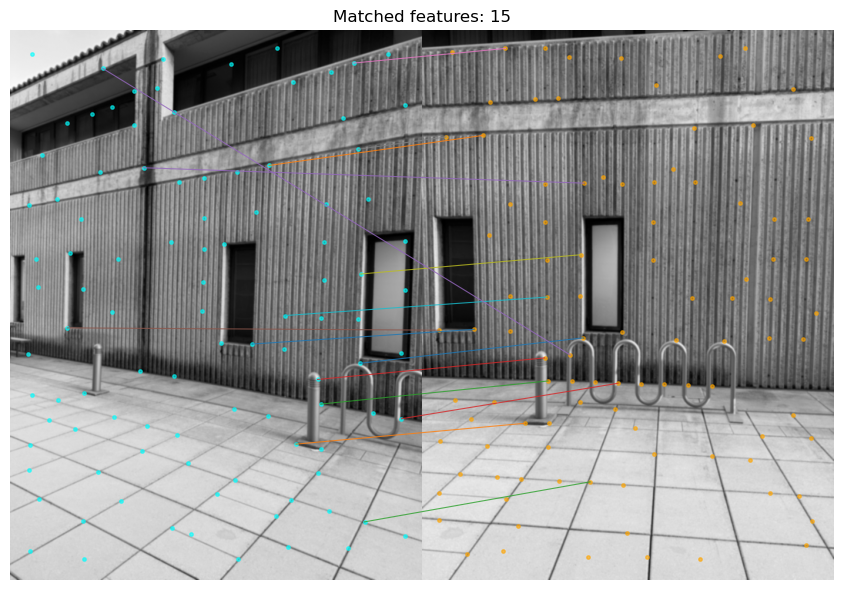

In [4]:
descs1, patches1 = extract_descriptors(img_small, coords_small_anms, return_patches=True)
descs2, patches2 = extract_descriptors(img_small2, coords_small_anms2, return_patches=True)

matches, ratios = match_descriptors_ratio(
    desc1=descs1, desc2=descs2,
    coords1=coords_small_anms, coords2=coords_small_anms2,
    ratio_thresh=0.8,        # 0.6~0.8
    mutual_check=True,       
    return_scores=True
)

print("num matches:", len(matches))

draw_matches_side_by_side(
    img1=img_small,
    img2=img_small2,
    coords1=coords_small_anms,
    coords2=coords_small_anms2,
    matches=matches,
    max_lines=200
)

In [5]:
from skimage.transform import ProjectiveTransform, warp

def _normalize_points(xy):
    mean = xy.mean(axis=0)
    d = np.sqrt(((xy - mean) ** 2).sum(axis=1)).mean() + 1e-12
    s = np.sqrt(2.0) / d
    T = np.array([[s, 0, -s * mean[0]],
                  [0, s, -s * mean[1]],
                  [0, 0, 1]], dtype=np.float64)
    xy_h = np.c_[xy, np.ones(len(xy))]
    xy_n_h = (T @ xy_h.T).T
    return xy_n_h[:, :2], T

def dlt_homography(xy1, xy2):
    assert xy1.shape == xy2.shape and xy1.shape[0] >= 4
    x1n, T1 = _normalize_points(xy1)
    x2n, T2 = _normalize_points(xy2)

    N = xy1.shape[0]
    A = np.zeros((2 * N, 9), dtype=np.float64)
    for i in range(N):
        x, y = x1n[i]; u, v = x2n[i]
        A[2*i]   = [-x, -y, -1,   0,  0,  0,  u*x, u*y, u]
        A[2*i+1] = [ 0,  0,  0,  -x, -y, -1,  v*x, v*y, v]
    _, _, Vt = np.linalg.svd(A)
    Hn = Vt[-1].reshape(3, 3)

    H = np.linalg.inv(T2) @ Hn @ T1
    return H / (H[2, 2] + 1e-12)

def _to_h(xy):
    return np.c_[xy, np.ones(len(xy))].T  # (3,N)

def warp_points(H, xy):
    uv_h = H @ _to_h(xy)
    uv = (uv_h[:2] / (uv_h[2:3] + 1e-12)).T
    return uv

def symmetric_transfer_error(H, xy1, xy2):
    Hinv = np.linalg.inv(H)
    p1to2 = warp_points(H, xy1)
    p2to1 = warp_points(Hinv, xy2)
    e12 = np.sum((xy2 - p1to2)**2, axis=1)
    e21 = np.sum((xy1 - p2to1)**2, axis=1)
    return e12 + e21

def ransac_homography_4pt(coords1, coords2, matches,
                           num_iters=2000, thresh=3.0, seed=None):
    rng = np.random.default_rng(seed)
    M = len(matches)
    if M < 4:
        return None, np.zeros(M, dtype=bool)

    p1 = np.stack([coords1[1, matches[:,0]], coords1[0, matches[:,0]]], axis=1)  # (M,2)
    p2 = np.stack([coords2[1, matches[:,1]], coords2[0, matches[:,1]]], axis=1)  # (M,2)

    best_inliers = None
    best_H = None
    best_cnt = -1
    th2 = (thresh**2) * 2 

    for _ in range(num_iters):
        idx = rng.choice(M, size=4, replace=False)
        H = dlt_homography(p1[idx], p2[idx])

        err = symmetric_transfer_error(H, p1, p2)
        inliers = err < th2
        cnt = int(inliers.sum())
        if cnt > best_cnt:
            best_cnt = cnt
            best_inliers = inliers
            best_H = H

    if best_cnt >= 4:
        H = dlt_homography(p1[best_inliers], p2[best_inliers])
        best_H = H

    return best_H, best_inliers

def stitch_pair(img1, img2, H12):
    if img1.ndim == 2:
        C = 1
        img1c = img1[..., None]
        img2c = img2[..., None]
    else:
        C = img1.shape[2]
        img1c = img1
        img2c = img2

    H1, W1 = img1c.shape[:2]
    H2, W2 = img2c.shape[:2]

    H21 = np.linalg.inv(H12)
    corners2 = np.array([[0,0],[W2,0],[W2,H2],[0,H2]], dtype=np.float64)
    warp_corners2 = warp_points(H21, corners2)

    corners1 = np.array([[0,0],[W1,0],[W1,H1],[0,H1]], dtype=np.float64)
    all_xy = np.vstack([corners1, warp_corners2])
    min_x, min_y = np.floor(all_xy.min(axis=0)).astype(int)
    max_x, max_y = np.ceil(all_xy.max(axis=0)).astype(int)

    tx, ty = -min_x, -min_y       
    out_w, out_h = max_x - min_x, max_y - min_y

    T = np.array([[1,0,tx],[0,1,ty],[0,0,1]], dtype=np.float64)
    Tinv = np.array([[1,0,-tx],[0,1,-ty],[0,0,1]], dtype=np.float64)

    Tf = ProjectiveTransform(matrix=Tinv)
    pano1 = warp(img1c, inverse_map=Tf, output_shape=(out_h, out_w), cval=0.0, preserve_range=True)

    K = H12 @ Tinv
    Kf = ProjectiveTransform(matrix=K)
    pano2 = warp(img2c, inverse_map=Kf, output_shape=(out_h, out_w), cval=0.0, preserve_range=True)

    ones1 = np.ones((H1, W1, 1), dtype=np.float32)
    mask1 = warp(ones1, inverse_map=Tf, output_shape=(out_h, out_w), cval=0.0, preserve_range=True)[...,0]
    ones2 = np.ones((H2, W2, 1), dtype=np.float32)
    mask2 = warp(ones2, inverse_map=Kf, output_shape=(out_h, out_w), cval=0.0, preserve_range=True)[...,0]

    eps = 1e-6
    den = (mask1 + mask2 + eps)[..., None]
    pano = (pano1 * mask1[..., None] + pano2 * mask2[..., None]) / den
    pano = np.clip(pano, 0.0, 1.0)

    if C == 1:
        pano = pano[..., 0]
    return pano.astype(np.float32)


RANSAC inliers: 8 / 15


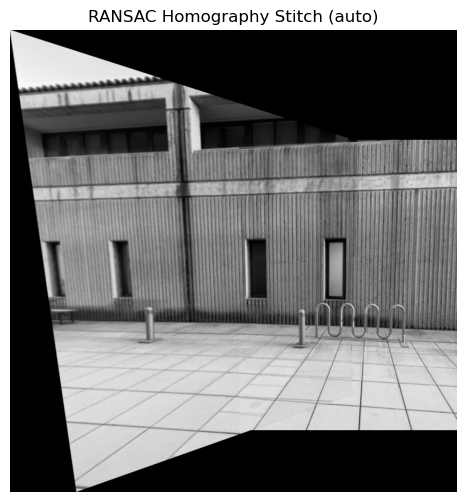

In [6]:
H12, inliers = ransac_homography_4pt(
    coords1=coords_small_anms,
    coords2=coords_small_anms2,
    matches=matches,
    num_iters=2000,
    thresh=3.0,   
    seed=0
)
print("RANSAC inliers:", int(inliers.sum()), "/", len(matches))

matches_in = matches[inliers]

pano = stitch_pair(img_small2, img_small, np.linalg.inv(H12))

plt.figure(figsize=(12,6))
plt.imshow(pano, cmap='gray' if pano.ndim==2 else None)
plt.title("RANSAC Homography Stitch (auto)")
plt.axis('off')
plt.show()


In [7]:
from skimage.filters import sobel_h, sobel_v

def estimate_orientations(
    img_gray, coords,        
    window_side=40,          
    num_bins=36,             
    sigma_frac=0.5           
):
    assert img_gray.ndim == 2
    H, W = img_gray.shape
    N = coords.shape[1]
    ys, xs = coords

    gx = sobel_h(img_gray.astype(np.float32))
    gy = sobel_v(img_gray.astype(np.float32))
    mag = np.sqrt(gx*gx + gy*gy).astype(np.float32)
    ang = np.arctan2(gy, gx).astype(np.float32)  # [-pi, pi]

    half = window_side / 2.0
    ys_off = np.arange(-int(np.floor(half)), int(np.ceil(half)), dtype=np.float32)
    xs_off = np.arange(-int(np.floor(half)), int(np.ceil(half)), dtype=np.float32)
    YY, XX = np.meshgrid(ys_off, xs_off, indexing='ij')  # (Sy,Sx)
    rr2 = YY**2 + XX**2
    sigma = sigma_frac * window_side
    w_gauss = np.exp(-0.5 * rr2 / (sigma*sigma)).astype(np.float32)

    thetas = np.empty(N, dtype=np.float32)
    bin_edges = np.linspace(-np.pi, np.pi, num_bins+1, dtype=np.float32)

    for i in range(N):
        yc = int(round(ys[i])); xc = int(round(xs[i]))

        y0 = yc - YY.shape[0]//2
        x0 = xc - XX.shape[1]//2
        y1 = y0 + YY.shape[0]
        x1 = x0 + XX.shape[1]

        yy0, yy1 = max(0, y0), min(H, y1)
        xx0, xx1 = max(0, x0), min(W, x1)
        if yy0 >= yy1 or xx0 >= xx1:
            thetas[i] = 0.0
            continue

        wy0, wy1 = yy0 - y0, yy1 - y0
        wx0, wx1 = xx0 - x0, xx1 - x0

        mag_win = mag[yy0:yy1, xx0:xx1]
        ang_win = ang[yy0:yy1, xx0:xx1]
        w_win   = w_gauss[wy0:wy1, wx0:wx1]

        hist, _ = np.histogram(ang_win.ravel(),
                               bins=bin_edges,
                               weights=(mag_win*w_win).ravel())
        k = int(np.argmax(hist))
        theta = 0.5 * (bin_edges[k] + bin_edges[k+1])
        thetas[i] = theta

    return thetas


def extract_descriptors_rotinv(
    img_gray, coords,
    patch_size=8, spacing=5,
    border="reflect",
    orientations=None,       
    return_patches=False
):
    assert img_gray.ndim == 2
    assert coords.ndim == 2 and coords.shape[0] == 2
    img = img_gray.astype(np.float32, copy=False)
    ys, xs = coords
    N = coords.shape[1]

    if orientations is None:
        orientations = estimate_orientations(img, coords, window_side=patch_size*spacing)

    half = (patch_size/2 - 0.5) * spacing
    offs = np.linspace(-half, half, patch_size, dtype=np.float32)
    V, U = np.meshgrid(offs, offs, indexing='ij')

    descs = np.empty((N, patch_size*patch_size), dtype=np.float32)
    patches = np.empty((N, patch_size, patch_size), dtype=np.float32) if return_patches else None

    for i in range(N):
        y0 = float(ys[i]); x0 = float(xs[i])
        th = float(orientations[i])
        c, s = np.cos(th), np.sin(th)

        X = x0 + (U * c - V * s)
        Y = y0 + (U * s + V * c)

        patch = bilinear_sample(img, Y, X, border=border)

        vec = patch.reshape(-1).astype(np.float32)
        m = vec.mean(); sd = vec.std()
        if sd < 1e-6:
            vec = vec - m
        else:
            vec = (vec - m) / sd

        descs[i] = vec
        if return_patches:
            patches[i] = patch

    return (descs, patches, orientations) if return_patches else (descs, orientations)




In [8]:
thetas = estimate_orientations(img_small, coords_small_anms, window_side=40)

descs_rot, patches_rot, _ = extract_descriptors_rotinv(
    img_gray=img_small,
    coords=coords_small_anms,
    patch_size=8,
    spacing=5,
    border="reflect",
    orientations=thetas, 
    return_patches=True
)

thetas2 = estimate_orientations(img_small2, coords_small_anms2, window_side=40)

descs_rot2, patches_rot2, _ = extract_descriptors_rotinv(
    img_gray=img_small2,
    coords=coords_small_anms2,
    patch_size=8,
    spacing=5,
    border="reflect",
    orientations=thetas2,
    return_patches=True
)

matches, ratios = match_descriptors_ratio(
    desc1=descs_rot, desc2=descs_rot2,
    coords1=coords_small_anms, coords2=coords_small_anms2,
    ratio_thresh=0.8, mutual_check=True, return_scores=True
)


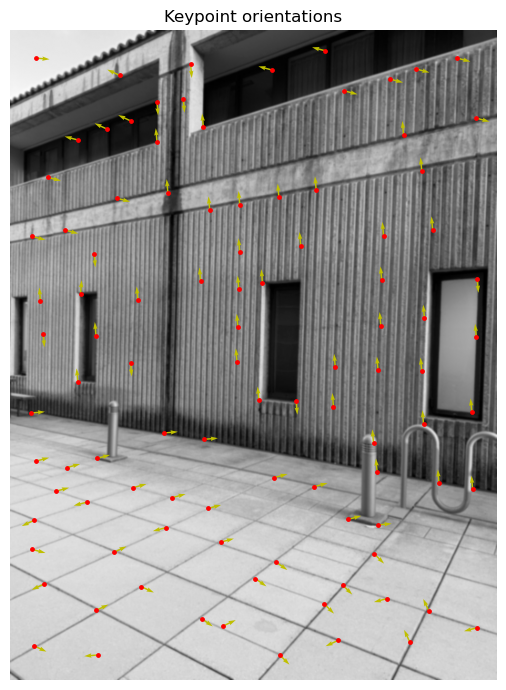

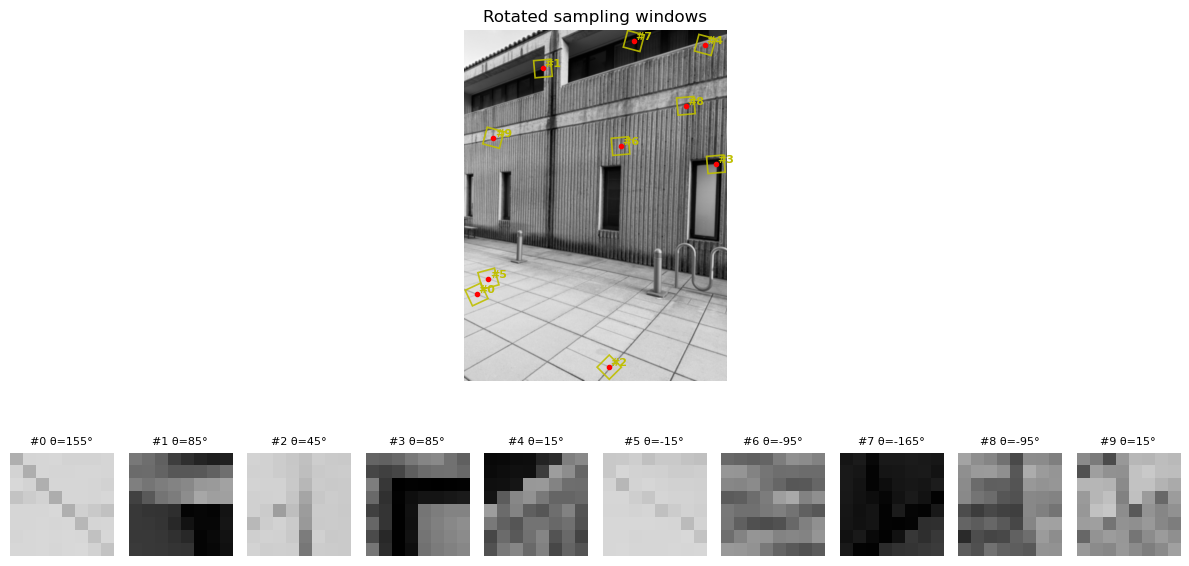

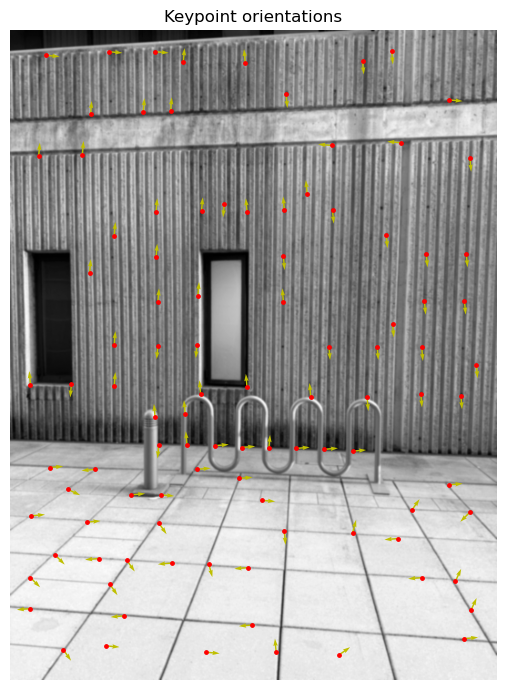

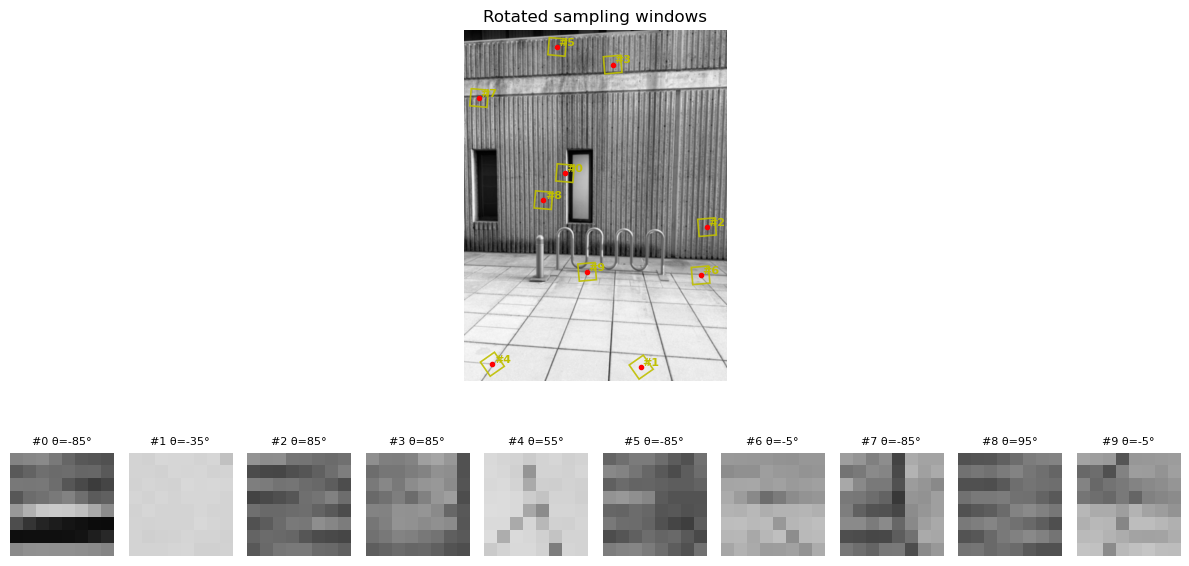

In [9]:
from matplotlib.patches import Polygon


def visualize_orientations(img_gray, coords, thetas, n=200, idxs=None, scale=15, seed=None, figsize=(7,7)):
    ys, xs = coords
    N = ys.shape[0] if ys.ndim==1 else ys.shape[0]  # 兼容
    if idxs is None:
        n = min(n, coords.shape[1])
        if seed is not None: random.seed(seed)
        idxs = random.sample(range(coords.shape[1]), n)
    else:
        idxs = list(idxs)
        n = min(n, len(idxs))

    x = coords[1, idxs]
    y = coords[0, idxs]
    th = thetas[idxs]

    u = np.cos(th) * scale
    v = np.sin(th) * scale

    plt.figure(figsize=figsize)
    plt.imshow(img_gray, cmap='gray')
    plt.quiver(x, y, u, v, angles='xy', scale_units='xy', scale=1, color='y', width=0.003)
    plt.scatter(x, y, s=6, c='r')
    plt.title("Keypoint orientations")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def visualize_rotated_patches(img_gray, coords, orientations, patches,
                              patch_size=8, spacing=5, n=10, idxs=None, seed=None, figsize=(12,7)):
    ys, xs = coords
    N = coords.shape[1]
    if idxs is None:
        n = min(n, N)
        if seed is not None: random.seed(seed)
        idxs = random.sample(range(N), n)
    else:
        idxs = list(idxs)
        n = min(n, len(idxs))

    half = (patch_size/2 - 0.5) * spacing
    square_local = np.array([
        [-half, -half],
        [ half, -half],
        [ half,  half],
        [-half,  half],
    ], dtype=np.float32)  # [[Ux,Uy], ...]

    cols = min(n, 10)
    rows = int(np.ceil(n / cols))
    fig = plt.figure(figsize=figsize)
    ax_main = plt.subplot2grid((rows+1, cols), (0,0), colspan=cols)
    ax_main.imshow(img_gray, cmap='gray')
    ax_main.set_title("Rotated sampling windows")
    ax_main.axis('off')

    for j in range(n):
        i = idxs[j]
        y0 = float(ys[i]); x0 = float(xs[i]); th = float(orientations[i])
        c, s = np.cos(th), np.sin(th)

        R = np.array([[c,-s],[s,c]], dtype=np.float32)
        sq_xy = (square_local @ R.T) + np.array([x0, y0], dtype=np.float32)  # (4,2)

        poly = Polygon(sq_xy, closed=True, fill=False, edgecolor='y', linewidth=1.2, alpha=0.9)
        ax_main.add_patch(poly)
        ax_main.plot(x0, y0, 'ro', markersize=3)
        ax_main.text(x0+3, y0-3, f'#{j}', color='y', fontsize=8, weight='bold')

        ax = plt.subplot2grid((rows+1, cols), (1 + j//cols, j%cols))
        ax.imshow(patches[i], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'#{j} θ={np.degrees(th):.0f}°', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()



visualize_orientations(img_small, coords_small_anms, thetas, n=200, seed=0)

visualize_rotated_patches(img_small, coords_small_anms, thetas, patches_rot,
                          patch_size=8, spacing=5, n=10, seed=0)

visualize_orientations(img_small2, coords_small_anms2, thetas2, n=200, seed=0)

visualize_rotated_patches(img_small2, coords_small_anms2, thetas2, patches_rot2,
                          patch_size=8, spacing=5, n=10, seed=0)

matches after ratio+mutual: 85
inliers: 35 / 85


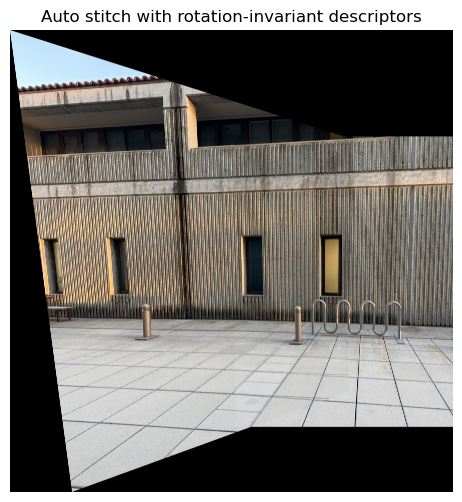

In [10]:
import numpy as np
from PIL import Image, ImageOps
from skimage import img_as_float

def upscale_homography(H_small, scale):
    S = np.array([[scale, 0, 0],
                  [0, scale, 0],
                  [0, 0, 1]], dtype=np.float64)
    H_full = S @ H_small @ np.linalg.inv(S)
    return H_full / (H_full[2,2] + 1e-12)

def autostitch_with_rotinv(
    img1_np, img2_np,     
    pyramid_levels=3,
    harris_keep=1200,     
    ratio_thresh=0.7,
    ransac_iters=2000,
    ransac_thresh_px=3.0,
    align="1->2",          
    seed=0,
    debug=False
):
    assert img1_np.ndim in (2,3) and img2_np.ndim in (2,3)
    if img1_np.ndim == 3:
        img1_gray = img_as_float(ImageOps.grayscale(Image.fromarray((img1_np*255).astype(np.uint8))))
    else:
        img1_gray = img1_np
    if img2_np.ndim == 3:
        img2_gray = img_as_float(ImageOps.grayscale(Image.fromarray((img2_np*255).astype(np.uint8))))
    else:
        img2_gray = img2_np

    pyr1 = build_gaussian_pyramid(img1_gray, levels=pyramid_levels)
    pyr2 = build_gaussian_pyramid(img2_gray, levels=pyramid_levels)
    L = pyramid_levels
    s = 2 ** L
    I1 = pyr1[L]
    I2 = pyr2[L]

    h1, c1 = get_harris_corners(I1)
    kpts1 = anms(h1, c1, num_keep=harris_keep, c_robust=0.9, return_radius=False)
    h2, c2 = get_harris_corners(I2)
    kpts2 = anms(h2, c2, num_keep=harris_keep, c_robust=0.9, return_radius=False)

    desc1, theta1 = extract_descriptors_rotinv(
        img_gray=I1, coords=kpts1, patch_size=8, spacing=5,
        border="reflect", orientations=None, return_patches=False
    )
    desc2, theta2 = extract_descriptors_rotinv(
        img_gray=I2, coords=kpts2, patch_size=8, spacing=5,
        border="reflect", orientations=None, return_patches=False
    )

    matches, ratios = match_descriptors_ratio(
        desc1, desc2, kpts1, kpts2,
        ratio_thresh=ratio_thresh, mutual_check=True, return_scores=True,
        dist_chunk=2048
    )
    if debug:
        print(f"matches after ratio+mutual: {len(matches)}")

    H_small, inliers = ransac_homography_4pt(
        coords1=kpts1, coords2=kpts2, matches=matches,
        num_iters=ransac_iters, thresh=ransac_thresh_px, seed=seed
    )
    matches_in = matches[inliers]
    if debug:
        print(f"inliers: {inliers.sum()} / {len(matches)}")

    H_full = upscale_homography(H_small, scale=s)

    if align == "1->2":
        pano = stitch_pair(img2_np, img1_np, np.linalg.inv(H_full))
    else:
        pano = stitch_pair(img1_np, img2_np, H_full)

    return pano, H_full, matches_in

img1 = Image.open(img1_path)
img2 = Image.open(img2_path)
img1_np = np.asarray(ImageOps.exif_transpose(img1)).astype(np.float32) / 255.0
img2_np = np.asarray(ImageOps.exif_transpose(img2)).astype(np.float32) / 255.0

pano, H12_full, matches_in = autostitch_with_rotinv(
    img1_np, img2_np,
    pyramid_levels=3,
    harris_keep=1200,
    ratio_thresh=0.8,
    ransac_iters=2000,
    ransac_thresh_px=3.0,
    align="1->2",
    seed=0,
    debug=True
)

plt.figure(figsize=(10,6))
plt.imshow(pano if pano.ndim==3 else np.clip(pano,0,1), cmap=None if pano.ndim==3 else 'gray')
plt.title("Auto stitch with rotation-invariant descriptors")
plt.axis('off')
plt.show()
